<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 5, Temporal Convolution Network**

Importamos lo necesario

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import statsmodels.api as sm

Importamos el dataset de CO2 atmosferico (Mauna Loa, statsmodels)

In [ ]:
import statsmodels.api as sm
data = sm.datasets.co2.load_pandas().data
data = data['co2'].interpolate()  # rellena NaNs
serie_np = data.values.astype('float32')

Normalizamos la serie para que la red entrene mejor

In [ ]:
media, std = serie_np.mean(), serie_np.std()
serie_norm = (serie_np - media) / std

Convertimos a tensor con forma (batch=1, canales=1, tiempo)

In [ ]:
serie = torch.tensor(serie_norm).unsqueeze(0).unsqueeze(0)

Definimos bloques causales de la TCN

In [ ]:
def causal_conv1d(in_c, out_c, k, d):
    # padding solo se necesita a la izquierda, pero Conv1d lo pone en ambos lados
    # por eso despues recortamos con "chomp"
    pad = (k - 1) * d
    conv = nn.Conv1d(in_c, out_c, k, padding=pad, dilation=d)
    return conv, pad

def chomp(x, pad):
    # quita el padding sobrante del lado derecho para mantener la causalidad
    return x[:, :, :-pad] if pad > 0 else x

def tcn_block(x, conv, pad):
    # convolucion causal + no linealidad
    return torch.relu(chomp(conv(x), pad))

def build_tcn(in_c, channels, k=3):
    # arma la lista de capas, cada una con dilatacion creciente (1,2,4,8,...)
    layers = []
    c_in = in_c
    for i, c_out in enumerate(channels):
        d = 2 ** i
        conv, pad = causal_conv1d(c_in, c_out, k, d)
        layers.append((conv, pad))
        c_in = c_out
    return layers

def tcn_forward(x, layers):
    # aplica cada capa en secuencia
    for conv, pad in layers:
        x = tcn_block(x, conv, pad)
    return x

Preparamos los datos de entrenamiento. La tarea es predecir el siguiente valor de la serie a partir del historial

In [ ]:
x_in = serie[:, :, :-1]
y_true = serie[:, :, 1:]

In [ ]:
torch.manual_seed(0)

Definimos la TCN con 3 capas: 16, 32, 1 canal de salida

In [ ]:
layers = build_tcn(in_c=1, channels=[16, 32, 1], k=3)

Juntamos los parametros de todas las capas para el optimizador

In [ ]:
params = [p for conv, _ in layers for p in conv.parameters()]
opt = torch.optim.Adam(params, lr=0.01)

Entrenamiento

In [ ]:
for epoch in range(300):
    opt.zero_grad()
    y_pred = tcn_forward(x_in, layers)
    loss = torch.mean((y_pred - y_true) ** 2)  # error cuadratico medio
    loss.backward()
    opt.step()
    if epoch % 50 == 0:
        print(epoch, loss.item())

0 0.9671813249588013
50 0.4593808352947235
100 0.45745569467544556
150 0.4560772478580475
200 0.4554055631160736
250 0.45523616671562195


Predicción final (des-normalizada)

In [ ]:
with torch.no_grad():
    pred_norm = tcn_forward(x_in, layers).squeeze().numpy()
pred_real = pred_norm * std + media

In [ ]:
print("Primeros valores predichos:", pred_real[:5])
print("Primeros valores reales:   ", serie_np[1:6])

Primeros valores predichos: [339.65247 339.65247 339.65247 339.65247 339.65247]
Primeros valores reales:    [317.3 317.6 317.5 316.4 316.9]


Visualizamos los resultados

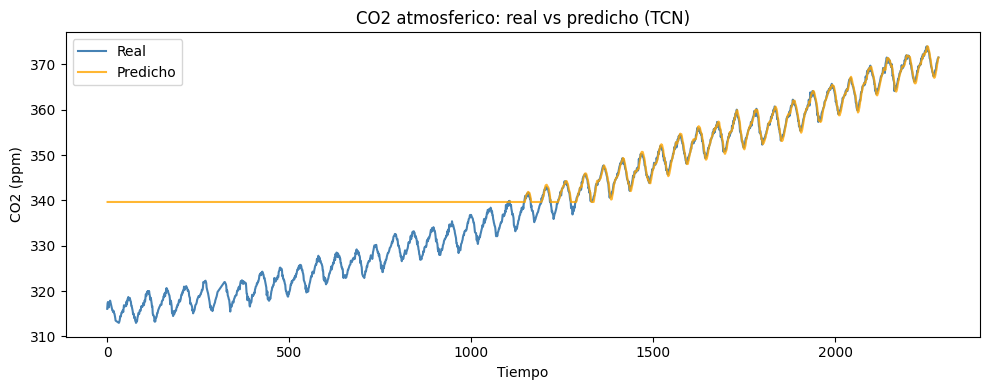

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(serie_np, label='Real', color='steelblue')
plt.plot(np.arange(1, len(pred_real) + 1), pred_real, label='Predicho', color='orange', alpha=0.8)
plt.title('CO2 atmosferico: real vs predicho (TCN)')
plt.xlabel('Tiempo')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.tight_layout()
plt.show()